[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter7_seminar_notebook.ipynb)

# Modelling Financial Markets — Seminar 7: Value-at-Risk and Expected Shortfall

*Seminar notebook. Daniel Traian Pele, Antoaneta Amza, Bucharest University of Economic Studies.*

- **[Solved]** problems contain the full solution; **[Proposed]** problems are solved by you.
- Part A: derivations (A1–A8); Part B: estimation and inference (B1–B7); Part C: open question.

> The solutions are discussed in the seminar.

In [ ]:
# On Colab, install arch first: !pip install arch
import os
import re
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, integrate
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [ ]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Gray     = '#7F7F7F'   # doar linii de referinta, benzi, grila
LightGray = '#DADADA'
Teal     = '#17A2B8'
METHOD_COL = {'HS': MainBlue, 'Normal': Orange, 'Student-t': Forest, 'Cornish-Fisher': Purple, 'EVT (GPD)': IDAred}

HERE = '.'
SEED = 42
ORDER = ['sp500', 'bet', 'btc', 'eurron', 'gold']
METHODS = ['HS', 'Normal', 'Student-t', 'Cornish-Fisher', 'EVT (GPD)']
B_BOOT = 2000


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)



import tempfile
HERE = tempfile.gettempdir()   # intermediate tables are written to a temporary folder


def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()

## Data

- Daily closes up to 18 September 2026: S&P 500, BET, Bitcoin, EUR/RON (BNR reference rate), gold (USD per troy ounce).
- Equity indices: weekdays only, days with an unchanged close removed; gold: weekdays only; Bitcoin: 7 days a week.
- Loss $L = -r$, daily log return in %; VaR and ES are positive numbers.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# nume -> (simbol, eticheta, tip, data de start)
MARKETS = {
    'sp500':  ('GSPC.INDX',    'S&P 500',                  'index',  '2000-01-01'),
    'bet':    ('BET',          'BET',                      'index',  '2000-01-01'),
    'btc':    ('BTC-USD.CC',   'Bitcoin',                  'crypto', '2014-09-17'),
    'eurron': ('REF:EUR',      'EUR/RON (reference rate)', 'fx',     '2005-07-01'),
    'gold':   ('XAUUSD.FOREX', 'Gold (XAU/USD)',           'fx',     '2000-01-01'),
}
# active pentru portofolii (join pe preturi in zilele comune)
ASSETS = {
    'SPY': ('SPY.US', 'adjusted_close'), 'TLT': ('TLT.US', 'adjusted_close'), 'GLD': ('GLD.US', 'adjusted_close'),
    'BTC': ('BTC-USD.CC', 'close'),
    'TLV': ('TLV.RO', 'adjusted_close'), 'SNP': ('SNP.RO', 'adjusted_close'), 'BRD': ('BRD.RO', 'adjusted_close'),
    'TGN': ('TGN.RO', 'adjusted_close'), 'SNG': ('SNG.RO', 'adjusted_close'), 'SNN': ('SNN.RO', 'adjusted_close'),
    'EL': ('EL.RO', 'adjusted_close'), 'FP': ('FP.RO', 'adjusted_close'), 'TEL': ('TEL.RO', 'adjusted_close'),
}
LABELS = {k: v[1] for k, v in MARKETS.items()}

_CACHE = {}


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Cursul oficial de referinta RON (arhive XML anuale BNR)."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END):
    """Pretul zilnic, curatat dupa conventiile capitolului."""
    symbol, _, kind, start0 = MARKETS[name]
    start = start or start0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    s = read_market(symbol)['close'].loc[start:end]
    s = s[s > 0].dropna()
    if kind != 'crypto':
        s = s[s.index.dayofweek < 5]          # fara cotatii de weekend
    if kind == 'index':
        s = s[s.diff() != 0]                  # fara sarbatori completate cu pretul anterior
    return s.rename(name)


def log_returns(name, start=None, end=END):
    """Randamente log pe calendarul propriu al seriei."""
    return np.log(load_close(name, start, end)).diff().dropna().rename(name)


def periods_per_year(r):
    """Frecventa reala: numarul mediu de observatii pe an calendaristic."""
    return len(r) / ((r.index[-1] - r.index[0]).days / 365.25)


def asset_price(key, end=END):
    symbol, col = ASSETS[key]
    s = read_market(symbol)[col].loc[:end]
    s = s[s > 0].dropna()
    if key != 'BTC':
        s = s[s.index.dayofweek < 5]
    return s.rename(key)


def joint_returns(keys, start=None, end=END):
    """Randamente log simple pentru mai multe active: join pe PRETURI in zilele comune, apoi randamente."""
    p = pd.concat([asset_price(k, end) for k in keys], axis=1, join='inner').dropna()
    if start:
        p = p.loc[start:]
    return np.log(p).diff().dropna()


# randamente log zilnice in %, pierderea L = -r
rets = {k: 100 * log_returns(k) for k in MARKETS}
loss = {k: -v for k, v in rets.items()}
for k in ORDER:
    print(f'{LABELS[k]:26s}', rets[k].index[0].date(), '->', rets[k].index[-1].date(), len(rets[k]), 'obs')

## Risk measures

- `hs_var_es`, `normal_var_es`, `t_var_es`, `cf_var_es`: historical, Normal distribution, Student-$t$, Cornish–Fisher.
- `gpd_fit`, `gpd_var_es`, `gpd_se`, `mean_excess`: peaks over threshold.
- `garch_filter`, `garch_next`, `fhs_mc`, `rolling_conditional`: AR(1)-GARCH(1,1) filtering, filtered historical simulation, conditional EVT.

In [ ]:
def hs_var_es(L, alpha):
    """Simulare istorica: VaR alpha = cuantila empirica 1 - alpha a pierderii; ES = media pierderilor de dincolo."""
    L = np.asarray(L)
    v = np.quantile(L, 1 - alpha)
    return v, L[L >= v].mean()


def normal_var_es(L, alpha):
    """Distributia Normala: VaR = -mu_X + sigma z_{1-alpha}, ES = -mu_X + sigma phi(z_alpha)/alpha (mu_L = -mu_X)."""
    mu, s = np.mean(L), np.std(L, ddof=1)
    z = stats.norm.ppf(1 - alpha)
    return mu + s * z, mu + s * stats.norm.pdf(z) / alpha


def t_fit(L):
    """Student-t cu locatie si scala, estimata prin verosimilitate maxima."""
    return stats.t.fit(np.asarray(L))


def t_var_es(L, alpha, params=None):
    """Student-t pe pierderi: VaR = m + s t_{1-alpha}, ES = m + s g(t_alpha)/alpha (nu + t_alpha^2)/(nu - 1)."""
    nu, m, s = params if params is not None else t_fit(L)
    q = stats.t.ppf(1 - alpha, nu)
    return m + s * q, m + s * stats.t.pdf(q, nu) / alpha * (nu + q ** 2) / (nu - 1)


def cf_quantile(z, S, K):
    """Cuantila Cornish-Fisher standardizata: z = cuantila Normala, S = asimetria, K = excesul de aplatizare."""
    return z + (z ** 2 - 1) * S / 6 + (z ** 3 - 3 * z) * K / 24 - (2 * z ** 3 - 5 * z) * S ** 2 / 36


def cf_var_es(L, alpha):
    """Cornish-Fisher pe randamente X = -L: VaR = -(mu_X + sigma z~_alpha); ES = media lui VaR_u pentru u in (0, alpha)."""
    X = -np.asarray(L)
    mu, s = X.mean(), X.std(ddof=1)
    S, K = stats.skew(X), stats.kurtosis(X)
    var = -(mu + s * cf_quantile(stats.norm.ppf(alpha), S, K))
    es = -integrate.quad(lambda u: mu + s * cf_quantile(stats.norm.ppf(u), S, K), 0, alpha, limit=200)[0] / alpha
    return var, es


def gpd_fit(L, tail=0.05):
    """POT: pragul u lasa deasupra proportia tail din pierderi; GPD estimata prin verosimilitate maxima pe excese."""
    L = np.asarray(L)
    u = np.quantile(L, 1 - tail)
    ex = L[L > u] - u
    xi, _, beta = stats.genpareto.fit(ex, floc=0)
    return dict(u=u, xi=xi, beta=beta, nu=len(ex), n=len(L))


def gpd_var_es(fit, alpha):
    """VaR si ES cu probabilitatea cozii alpha din coada GPD (estimatorul de tip Smith)."""
    u, xi, beta, nu, n = fit['u'], fit['xi'], fit['beta'], fit['nu'], fit['n']
    var = u + beta / xi * (((n / nu) * alpha) ** (-xi) - 1)
    return var, var / (1 - xi) + (beta - xi * u) / (1 - xi)


def gpd_se(fit):
    """Erori standard asimptotice ale MLE pentru GPD (xi > -1/2)."""
    xi, beta, nu = fit['xi'], fit['beta'], fit['nu']
    return np.sqrt((1 + xi) ** 2 / nu), np.sqrt(2 * beta ** 2 * (1 + xi) / nu)


def mean_excess(L, us):
    """Functia de exces mediu e(u) = E[L - u | L > u] pe o grila de praguri."""
    L = np.asarray(L)
    return np.array([(L[L > u] - u).mean() for u in us]), np.array([(L > u).sum() for u in us])


def garch_filter(r, params=None, last_obs=None):
    """AR(1)-GARCH(1,1) cu QML Normal (Capitolul 5); r in %.
    Intoarce modelul estimat (pana la last_obs) si seriile mu_t, sigma_t pentru toata selectia."""
    am = arch_model(r, mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='normal', rescale=False)
    if params is None:
        params = am.fit(disp='off', last_obs=last_obs).params
    fx = am.fix(params)
    sig = fx.conditional_volatility
    mu = r - fx.resid
    return params, mu, sig


def garch_next(r, params):
    """Media si volatilitatea conditionate pentru ziua urmatoare ultimei observatii."""
    c, phi, om, al, be = params.values[:5]
    _, mu, sig = garch_filter(r, params)
    e = r.iloc[-1] - mu.iloc[-1]
    return c + phi * r.iloc[-1], np.sqrt(om + al * e ** 2 + be * sig.iloc[-1] ** 2)


def fhs_mc(r, params, z, h, n_paths=100_000, seed=42):
    """Monte Carlo FHS: traiectorii AR(1)-GARCH(1,1) pe h zile cu reziduuri standardizate reesantionate.
    Intoarce pierderile cumulate pe h zile (in %, randamente log)."""
    rng = np.random.default_rng(seed)
    c, phi, om, al, be = params.values[:5]
    _, mu, sig = garch_filter(r, params)
    r_prev = np.full(n_paths, r.iloc[-1])
    e_prev = np.full(n_paths, r.iloc[-1] - mu.iloc[-1])
    s2_prev = np.full(n_paths, sig.iloc[-1] ** 2)
    tot = np.zeros(n_paths)
    for _ in range(h):
        s2 = om + al * e_prev ** 2 + be * s2_prev
        e = np.sqrt(s2) * rng.choice(z, n_paths)
        r_new = c + phi * r_prev + e
        tot += r_new
        r_prev, e_prev, s2_prev = r_new, e, s2
    return -tot


def rolling_conditional(r, first_year, window_hs=500, alpha=0.01, tail_evt=0.10):
    """VaR/ES conditionat zi de zi: parametrii AR(1)-GARCH re-estimati la fiecare inceput de an
    pe toate datele anterioare; FHS si EVT conditionat folosesc reziduurile standardizate anterioare.
    Pentru comparatie: HS pe fereastra mobila de window_hs zile. Fara informatie din viitor."""
    out = []
    L = -r
    for y in range(first_year, r.index[-1].year + 1):
        est = r.loc[:f'{y - 1}-12-31']
        params, mu, sig = garch_filter(r, last_obs=f'{y}-01-01')
        z = ((est - mu.loc[est.index]) / sig.loc[est.index]).dropna()
        nz = -z.values
        fz = gpd_fit(nz, tail_evt)
        q_fhs, q_evt_v = np.quantile(nz, 1 - alpha), gpd_var_es(fz, alpha)[0]
        es_fhs = nz[nz >= q_fhs].mean()
        es_evt = gpd_var_es(fz, alpha)[1]
        days = r.loc[f'{y}-01-01':f'{y}-12-31'].index
        for d in days:
            i = r.index.get_loc(d)
            past = L.iloc[max(0, i - window_hs):i]
            out.append((d, L.loc[d], -mu.loc[d] + sig.loc[d] * q_fhs, -mu.loc[d] + sig.loc[d] * es_fhs,
                        -mu.loc[d] + sig.loc[d] * q_evt_v, -mu.loc[d] + sig.loc[d] * es_evt,
                        -mu.loc[d] + sig.loc[d] * stats.norm.ppf(1 - alpha), np.quantile(past, 1 - alpha), sig.loc[d]))
    return pd.DataFrame(out, columns=['date', 'loss', 'fhs_var', 'fhs_es', 'cevt_var', 'cevt_es', 'ngarch_var',
                                      'hs_var', 'sigma']).set_index('date')

## Seminar functions

- Discrete VaR/ES, bootstrap intervals and the tables used in Part B (from `seminar7.py`).

In [ ]:
B_BOOT = 2000
BVB = ['TLV', 'SNP', 'BRD', 'TGN', 'SNG', 'SNN', 'EL', 'TEL']
C_START = '2016-09-19'


def discrete_var_es(values, probs, alpha):
    """VaR si ES cu probabilitatea cozii alpha pentru o pierdere discreta L = -X (formula Acerbi-Tasche).
    VaR_alpha = -inf{x : P(X <= x) > alpha}; ES_alpha = (E[L 1{L > VaR}] + VaR (alpha - P(L > VaR))) / alpha."""
    order = np.argsort(values)
    x, p = np.asarray(values)[order], np.asarray(probs)[order]
    cdf = np.cumsum(p)
    var = x[np.searchsorted(cdf, 1 - alpha - 1e-12)]
    tail = x > var
    es = ((x[tail] * p[tail]).sum() + var * (alpha - p[tail].sum())) / alpha
    return var, es


def all_methods(L, alpha):
    """VaR si ES la nivelul a pentru toate metodele necondiționate."""
    f = gpd_fit(L, 0.05)
    return {'HS': hs_var_es(L, alpha), 'Normal': normal_var_es(L, alpha), 'Student-t': t_var_es(L, alpha),
            'Cornish-Fisher': cf_var_es(L, alpha), 'EVT (GPD)': gpd_var_es(f, alpha)}


def summary_table():
    """Statistici descriptive si VaR/ES (1%, 2.5%) pe metode pentru cele cinci serii."""
    rows = {}
    for k in ORDER:
        L = loss[k]
        nu, m, s = t_fit(L)
        f = gpd_fit(L, 0.05)
        row = dict(N=len(L), start=str(L.index[0].date()), mean=L.mean(), sd=L.std(), skew=stats.skew(L),
                   kurt=stats.kurtosis(L), max=L.max(), max_date=str(L.idxmax().date()), t_nu=nu, t_loc=m, t_scale=s,
                   gpd_u=f['u'], gpd_xi=f['xi'], gpd_beta=f['beta'], gpd_nu=f['nu'],
                   gpd_xi_se=gpd_se(f)[0], ppy=periods_per_year(L))
        for a, tag in [(0.01, '1%'), (0.025, '2.5%')]:
            for meth, (v, e) in all_methods(L, a).items():
                row[f'{meth}|VaR {tag}'] = v
                row[f'{meth}|ES {tag}'] = e
        rows[k] = row
    t = pd.DataFrame(rows).T
    t.to_csv(os.path.join(HERE, 'ch7_var_es_table.csv'))
    return t


def boot_ci(L, fun, B=B_BOOT, block=None, seed=SEED):
    """Interval bootstrap percentil 95%: i.i.d. (block=None) sau pe blocuri mobile de lungime block."""
    rng = np.random.default_rng(seed)
    L = np.asarray(L)
    n = len(L)
    stats_ = np.empty(B)
    for b in range(B):
        if block is None:
            x = L[rng.integers(0, n, n)]
        else:
            starts = rng.integers(0, n - block + 1, int(np.ceil(n / block)))
            x = np.concatenate([L[s:s + block] for s in starts])[:n]
        stats_[b] = fun(x)
    return np.percentile(stats_, [2.5, 97.5]), stats_


# tables reused in B3 and B4
t = summary_table()
rolling_conditional(rets['btc'], 2017).to_csv(os.path.join(HERE, 'ch7_rolling_btc.csv'))

In [ ]:
from scipy import optimize, signal


def nw_lrv(x):
    """Dispersia de termen lung (Newey-West, nucleu Bartlett, decalaj floor(4 (n/100)^(2/9)))."""
    x = np.asarray(x, float) - np.mean(x)
    n = len(x)
    m = int(np.floor(4 * (n / 100) ** (2 / 9)))
    s = x @ x / n
    for j in range(1, m + 1):
        s += 2 * (1 - j / (m + 1)) * (x[j:] @ x[:-j]) / n
    return s, m


def var_es_se(L, a_var=0.01, a_es=0.025):
    """VaR istoric: avar = a(1-a)/f(q)^2 (densitate prin nucleu Gaussian, regula lui Silverman);
    ES istoric (Chen, 2008): functia de influenta VaR + (L - VaR)_+/a - ES, avar = Var((L - VaR)_+)/a^2.
    Varianta HAC: dispersia de termen lung a indicatorului, respectiv a lui (L - VaR)_+."""
    L = np.asarray(L, float)
    n = len(L)
    v = np.quantile(L, 1 - a_var)
    f = stats.gaussian_kde(L, bw_method='silverman')(v)[0]
    ind = (L > v).astype(float)
    se_v = np.sqrt(a_var * (1 - a_var) / n) / f
    se_v_hac = np.sqrt(nw_lrv(ind)[0] / n) / f
    v2, e2 = hs_var_es(L, a_es)
    ex = np.maximum(L - v2, 0)
    se_e = ex.std(ddof=1) / (a_es * np.sqrt(n))
    lrv, m = nw_lrv(ex)
    se_e_hac = np.sqrt(lrv / n) / a_es
    return dict(n=n, var1=v, f=f, se_var=se_v, se_var_hac=se_v_hac, es=e2, var_es=v2, se_es=se_e,
                se_es_hac=se_e_hac, lag=m, ntail=a_es * n)


def se_theory(sigma=1.2, n=500, nu=4, alpha=0.01):
    """SE asimptotic al VaR 1% istoric sub distributia Normala si sub Student-t (aceeasi abatere standard)."""
    z = stats.norm.ppf(1 - alpha)
    f_n = stats.norm.pdf(z) / sigma
    s = sigma * np.sqrt((nu - 2) / nu)
    q = stats.t.ppf(1 - alpha, nu)
    f_t = stats.t.pdf(q, nu) / s
    c = np.sqrt(alpha * (1 - alpha) / n)
    return dict(se_normal=c / f_n, se_t=c / f_t, q_normal=sigma * z, q_t=s * q)


def ru_objective(L, v, alpha):
    return v + np.maximum(np.asarray(L) - v, 0).mean() / alpha


def ru_check(L, alpha=0.025):
    L = np.asarray(L, float)
    res = optimize.minimize_scalar(lambda v: ru_objective(L, v, alpha), bounds=(0, L.max()), method='bounded',
                                   options=dict(xatol=1e-8))
    v, e = hs_var_es(L, alpha)
    return dict(argmin=res.x, min=res.fun, var=v, es=e)


def min_es_portfolio(R, alpha=0.025):
    """ES minim pe scenarii (Rockafellar & Uryasev, 2000): min v + 1/(alpha N) sum u_s,
    u_s >= -R_s w - v, u_s >= 0, sum w = 1, w >= 0 (fara vanzari in lipsa)."""
    N, d = R.shape
    c = np.concatenate([np.zeros(d), [1.0], np.full(N, 1 / (alpha * N))])
    from scipy.sparse import csr_matrix, hstack as sh, identity
    A = sh([csr_matrix(-R), csr_matrix(-np.ones((N, 1))), -identity(N)]).tocsr()
    b = np.zeros(N)
    Aeq = np.concatenate([np.ones(d), [0.0], np.zeros(N)])[None, :]
    bounds = [(0, None)] * d + [(None, None)] + [(0, None)] * N
    out = optimize.linprog(c, A_ub=A, b_ub=b, A_eq=Aeq, b_eq=[1.0], bounds=bounds, method='highs')
    return out.x[:d], out.x[d], out.fun


def min_var_portfolio(R):
    S = np.cov(R.T)
    d = S.shape[0]
    res = optimize.minimize(lambda w: w @ S @ w, np.full(d, 1 / d), bounds=[(0, 1)] * d,
                            constraints=[dict(type='eq', fun=lambda w: w.sum() - 1)], method='SLSQP',
                            options=dict(ftol=1e-14, maxiter=500))
    return res.x


def drop_largest(L, alpha_var=0.01, alpha_es=0.025):
    """Sensibilitatea la o singura observatie: VaR 1% si ES 2,5% istorice cu si fara cea mai mare pierdere."""
    L = np.asarray(L, float)
    L2 = np.delete(L, np.argmax(L))
    return dict(max=L.max(), var=np.quantile(L, 1 - alpha_var), var_drop=np.quantile(L2, 1 - alpha_var),
                es=hs_var_es(L, alpha_es)[1], es_drop=hs_var_es(L2, alpha_es)[1])


def rearrangement(X, tol=1e-10, max_iter=1000):
    X = X.copy()
    for _ in range(max_iter):
        old = X.copy()
        for j in range(X.shape[1]):
            rest = X.sum(axis=1) - X[:, j]
            X[np.argsort(rest), j] = np.sort(X[:, j])[::-1]    # ordonare opusa fata de suma celorlalte coloane
        if np.max(np.abs(X - old)) < tol:
            break
    return X


def worst_var_ra(Lcols, alpha=0.01, N=2000):
    """VaR 1% maxim al sumei cu marginale date (Embrechts, Puccetti & Rueschendorf, 2013):
    discretizam coada de probabilitate alpha a fiecarei marginale in N puncte (jos / sus) si rearanjam;
    VaR-ul cel mai rau ~ minimul sumelor pe randuri."""
    lo = np.column_stack([np.quantile(x, 1 - alpha + alpha * np.arange(N) / N) for x in Lcols])
    hi = np.column_stack([np.quantile(x, 1 - alpha + alpha * np.arange(1, N + 1) / N) for x in Lcols])
    return rearrangement(lo).sum(axis=1).min(), rearrangement(hi).sum(axis=1).min()


def aggregation(alpha=0.01):
    W = np.array([0.40, 0.30, 0.20, 0.10])
    lr = joint_returns(['SPY', 'TLT', 'GLD', 'BTC'], start='2014-09-18')
    R = 100 * (np.exp(lr) - 1)
    Lw = [-(R.values[:, i] * W[i]) for i in range(4)]
    como = sum(np.quantile(x, 1 - alpha) for x in Lw)
    hist = np.quantile(-(R.values @ W), 1 - alpha)
    lo, hi = worst_var_ra(Lw, alpha)
    # ES minim (LP) si portofoliul de dispersie minima, alpha = 2.5%
    w_es, v_es, es_min = min_es_portfolio(R.values, 0.025)
    w_mv = min_var_portfolio(R.values)
    es_mv = hs_var_es(-(R.values @ w_mv), 0.025)[1]
    es_ew = hs_var_es(-(R.values @ W), 0.025)[1]
    sd_es = np.std(R.values @ w_es, ddof=1)
    sd_mv = np.std(R.values @ w_mv, ddof=1)
    return dict(N=len(R), var_hist=hist, var_como=como, var_worst_lo=lo, var_worst_hi=hi,
                w_es=w_es, es_min=es_min, v_es=v_es, w_mv=w_mv, es_mv=es_mv, es_4030=es_ew, sd_es=sd_es, sd_mv=sd_mv)


def fhs_bootstrap(r, alpha=0.01, B=999, seed=SEED, level=0.90):
    """Christoffersen & Goncalves (2005): traiectorii AR(1)-GARCH(1,1) cu reziduuri reesantionate;
    re-estimam parametrii pe fiecare traiectorie; sigma_{T+1} din datele ORIGINALE cu parametrii bootstrap;
    cuantila din reziduurile standardizate ale traiectoriei bootstrap."""
    rng = np.random.default_rng(seed)
    params, mu, sig = garch_filter(r)
    z = ((r - mu) / sig).dropna().values
    m1, s1 = garch_next(r, params)
    var0 = -m1 + s1 * np.quantile(-z, 1 - alpha)
    c, phi, om, al, be = params.values[:5]
    n = len(r)
    out = np.empty(B)
    parts = np.empty((B, 2))
    for b in range(B):
        zz = rng.choice(z, n)
        rs = np.empty(n)
        s2 = om / (1 - al - be)
        rp, ep = r.iloc[0], 0.0
        for t in range(n):
            s2 = om + al * ep ** 2 + be * s2 if t > 0 else s2
            e = np.sqrt(s2) * zz[t]
            rs[t] = c + phi * rp + e
            rp, ep = rs[t], e
        rs = pd.Series(rs, index=r.index)
        pb, mub, sgb = garch_filter(rs)
        zb = ((rs - mub) / sgb).dropna().values
        mb, sb = garch_next(r, pb)                    # istoria ORIGINALA, parametrii bootstrap
        qb = np.quantile(-zb, 1 - alpha)
        out[b] = -mb + sb * qb
        parts[b] = [sb, qb]
    lo, hi = np.quantile(out, [(1 - level) / 2, (1 + level) / 2])
    # descompunere: doar incertitudinea cuantilei (sigma fixat) vs doar a lui sigma (cuantila fixata)
    q0 = np.quantile(-z, 1 - alpha)
    only_q = np.quantile(-m1 + s1 * parts[:, 1], [(1 - level) / 2, (1 + level) / 2])
    only_s = np.quantile(-m1 + parts[:, 0] * q0, [(1 - level) / 2, (1 + level) / 2])
    return dict(var=var0, lo=lo, hi=hi, sd=out.std(ddof=1), B=B, level=level, sigma=s1,
                sig_lo=np.quantile(parts[:, 0], (1 - level) / 2), sig_hi=np.quantile(parts[:, 0], (1 + level) / 2),
                q=q0, q_lo=np.quantile(parts[:, 1], (1 - level) / 2), q_hi=np.quantile(parts[:, 1], (1 + level) / 2),
                onlyq_lo=only_q[0], onlyq_hi=only_q[1], onlys_lo=only_s[0], onlys_hi=only_s[1])


def caviar_path(beta, r, v0):
    """VaR_t = b0 + b1 VaR_{t-1} + b2 |r_{t-1}| (VaR pozitiv; cuantila q_t = -VaR_t)."""
    b0, b1, b2 = beta
    x = b0 + b2 * np.abs(np.asarray(r, float)[:-1])
    rest = signal.lfilter([1.0], [1.0, -b1], x, zi=[b1 * v0])[0]
    return np.concatenate([[v0], rest])


def pinball(r, q, alpha):
    """Pierderea pinball (tick) medie pentru cuantila q a randamentului: (alpha - 1{r < q})(r - q)."""
    return np.mean((alpha - (r < q)) * (r - q))


def caviar_fit(r, alpha=0.01, n_rand=10_000, n_best=10, seed=SEED):
    """Engle & Manganelli (2004): 10^4 vectori initiali U(0,1), cei mai buni 10 rafinati alternand simplex
    si quasi-Newton pana la convergenta; VaR initial = cuantila empirica a primelor 300 de observatii."""
    r = np.asarray(r, float)
    v0 = -np.quantile(r[:300], alpha)
    obj = lambda b: pinball(r, -caviar_path(b, r, v0), alpha) if abs(b[1]) < 1 else 1e6  # noqa: E731
    rng = np.random.default_rng(seed)
    cand = rng.uniform(0, 1, (n_rand, 3))
    vals = np.array([obj(b) for b in cand])
    best = []
    for b in cand[np.argsort(vals)[:n_best]]:
        f_old = np.inf
        for _ in range(20):
            b = optimize.minimize(obj, b, method='Nelder-Mead', options=dict(xatol=1e-8, fatol=1e-12, maxiter=4000)).x
            b = optimize.minimize(obj, b, method='BFGS').x
            f = obj(b)
            if f_old - f < 1e-12:
                break
            f_old = f
        best.append((obj(b), b))
    f, b = min(best, key=lambda x: x[0])
    return b, v0, f


def caviar_study(name, est_end='2015-12-31', oos_start='2016-01-01', alpha=0.01, fhs=None):
    r = 100 * log_returns(name)
    b, v0, f = caviar_fit(r.loc[:est_end].values, alpha)
    v = pd.Series(caviar_path(b, r.values, v0), index=r.index)
    L = -r
    oos = r.loc[oos_start:].index
    out = dict(b0=b[0], b1=b[1], b2=b[2], n_est=int(len(r.loc[:est_end])), n_oos=int(len(oos)),
               hit_caviar=float((L.loc[oos] > v.loc[oos]).mean()),
               n_hit_caviar=int((L.loc[oos] > v.loc[oos]).sum()),
               pin_caviar=pinball(r.loc[oos].values, -v.loc[oos].values, alpha))
    if fhs is not None:
        d = fhs.loc[oos_start:]
        out.update(hit_fhs=float((d['loss'] > d['fhs_var']).mean()), n_hit_fhs=int((d['loss'] > d['fhs_var']).sum()),
                   pin_fhs=pinball(-d['loss'].values, -d['fhs_var'].values, alpha),
                   hit_hs=float((d['loss'] > d['hs_var']).mean()), n_hit_hs=int((d['loss'] > d['hs_var']).sum()),
                   pin_hs=pinball(-d['loss'].values, -d['hs_var'].values, alpha))
        cov = d.loc['2020-02-20':'2020-04-30']
        vc = v.loc[cov.index]
        out.update(covid_hit_caviar=int((cov['loss'] > vc).sum()), covid_hit_fhs=int((cov['loss'] > cov['fhs_var']).sum()),
                   covid_hit_hs=int((cov['loss'] > cov['hs_var']).sum()),
                   covid_max_caviar=float(vc.max()), covid_max_fhs=float(cov['fhs_var'].max()),
                   covid_max_hs=float(cov['hs_var'].max()), covid_days=int(len(cov)))
    return out, v


def fig_caviar(v, fhs, name='sp500', title='S&P 500', start='2016-01-01'):
    d = fhs.loc[start:]
    fig, ax = plt.subplots(figsize=(10, 3.3))
    ax.bar(d.index, d['loss'].clip(lower=0), width=1.5, color=Teal, alpha=0.45, label='Daily loss (gains set to 0)')
    ax.plot(d.index, v.loc[d.index], color=MainBlue, lw=0.9, label='CAViaR (SAV) VaR 1%, parameters from 2000-2015')
    ax.plot(d.index, d['fhs_var'], color=IDAred, lw=0.8, label='FHS VaR 1%, re-estimated every January')
    ax.set_ylabel('Daily loss (%)')
    ax.set_title(f'{title}, 2016-2026: one-day-ahead VaR 1% out of sample')
    legend_outside_bottom(ax, 3, -0.14)
    save_fig(f'ch7_caviar' if name == 'sp500' else f'ch7_sem_caviar_{name}')


def extremal_index(L, tail=0.05):
    """Estimatorul pe intervale: timpii dintre depasiri T_i; declusterizare cu cei mai mari C - 1 timpi,
    C = floor(theta N) + 1; GPD pe maximele clusterelor."""
    L = np.asarray(L, float)
    u = np.quantile(L, 1 - tail)
    S = np.flatnonzero(L > u)
    T = np.diff(S).astype(float)
    N = len(S)
    if T.max() <= 2:
        th = 2 * T.sum() ** 2 / ((N - 1) * (T ** 2).sum())
    else:
        th = 2 * (T - 1).sum() ** 2 / ((N - 1) * ((T - 1) * (T - 2)).sum())
    th = min(1.0, th)
    C = int(np.floor(th * N)) + 1
    cut = np.sort(T)[::-1][C - 2] if C > 1 else np.inf           # al (C-1)-lea cel mai mare timp
    breaks = np.flatnonzero(T > cut) if np.sum(T >= cut) > C - 1 else np.flatnonzero(T >= cut)
    groups = np.split(np.arange(N), breaks + 1)
    cmax = np.array([L[S[g]].max() for g in groups])
    xi, _, beta = stats.genpareto.fit(cmax - u, floc=0)
    fc = dict(u=u, xi=xi, beta=beta, nu=len(cmax), n=len(L))
    f = gpd_fit(L, tail)
    return dict(u=u, N=N, theta=th, n_clusters=len(groups), mean_size=N / len(groups),
                xi=f['xi'], se_xi=gpd_se(f)[0], xi_c=xi, se_xi_c=gpd_se(fc)[0], beta_c=beta,
                se_xi_eff=(1 + f['xi']) / np.sqrt(th * N))


def gev_theta(theta):
    """VaR 1% zilnic din maximele lunare cu corectia indicelui extremal: H^{-1}((1-alpha)^{n theta})."""
    r = 100 * log_returns('sp500')
    L = -r
    M = L.groupby([L.index.year, L.index.month]).max()
    n_block = L.groupby([L.index.year, L.index.month]).size().mean()
    c, loc, scale = stats.genextreme.fit(M.values)
    return dict(var1=stats.genextreme.ppf(0.99 ** n_block, c, loc, scale),
                var1_theta=stats.genextreme.ppf(0.99 ** (n_block * theta), c, loc, scale),
                pow_theta=0.99 ** (n_block * theta))


def seminar_extras():
    out = {}
    # A8: dispersia asimptotica a ES 2,5% istoric sub N(0, 1): Var((L - v)_+) / alpha^2, momente de Normala trunchiata
    a = 0.025
    v = stats.norm.ppf(1 - a)
    m1 = stats.norm.pdf(v) - v * a                       # E[(L - v)_+]
    m2 = (1 + v ** 2) * a - v * stats.norm.pdf(v)        # E[(L - v)_+^2]
    avar = (m2 - m1 ** 2) / a ** 2
    out['a8'] = dict(v=v, phi=stats.norm.pdf(v), m1=m1, m2=m2, var=m2 - m1 ** 2, avar=avar,
                     se500=np.sqrt(avar / 500), se500_pct=1.2 * np.sqrt(avar / 500), es=stats.norm.pdf(v) / a)
    # A6': monotonia hartii Cornish-Fisher pe z in [z_0.1%, 0]: derivata a z^2 + b z + c > 0
    def dmin(S, K):
        z = np.linspace(stats.norm.ppf(0.001), 0, 20001)
        return (1 + z * S / 3 + (3 * z ** 2 - 3) * K / 24 - (6 * z ** 2 - 5) * S ** 2 / 36).min()
    S = -0.5
    kmax = optimize.brentq(lambda K: dmin(S, K), 0.1, 30)
    kmax0 = optimize.brentq(lambda K: dmin(0.0, K), 0.1, 30)
    out['a6'] = dict(kmax=kmax, kmax0=kmax0, d3=dmin(S, 3.0), d10=dmin(S, 10.0))
    # A1': SE asimptotic al VaR 1% istoric sub N(0.04, 1.2^2)
    z = stats.norm.ppf(0.01)
    out['a1'] = dict(f=stats.norm.pdf(z) / 1.2, se500=1.2 * np.sqrt(0.01 * 0.99 / 500) / stats.norm.pdf(z),
                     se6670=1.2 * np.sqrt(0.01 * 0.99 / 6670) / stats.norm.pdf(z))
    # B1(c): BET, VaR 1%: interval asimptotic (densitate prin nucleu) si bootstrap pe blocuri (20 de zile)
    L = (-100 * log_returns('bet')).values
    for tag, x in [('full', L), ('w500', L[-500:])]:
        se = var_es_se(x)
        ci_blk, _ = boot_ci(x, lambda y: hs_var_es(y, 0.01)[0], block=20)
        out[f'b1_{tag}'] = dict(var1=se['var1'], f=se['f'], se=se['se_var'], se_hac=se['se_var_hac'],
                                lo=se['var1'] - 1.96 * se['se_var'], hi=se['var1'] + 1.96 * se['se_var'],
                                lo_hac=se['var1'] - 1.96 * se['se_var_hac'], hi_hac=se['var1'] + 1.96 * se['se_var_hac'],
                                blk_lo=ci_blk[0], blk_hi=ci_blk[1])
    return out

## Part A — derivations

### A1. Normal VaR and ES: derivation and precision [Solved]

- $r \sim N(0.04\%, 1.2\%^2)$: derive ES, VaR and ES at 1% and 2.5%; asymptotic SE of the historical VaR 1% for $n = 500$ and $n = 6\,670$.

In [7]:
# Solution
def a1_normal(mu=0.04, sigma=1.2, position=1_000_000):
    """VaR si ES pentru distributia Normala, pas cu pas: X ~ N(mu, sigma^2) (randamente in %),
    VaR_alpha = -(mu + sigma z_alpha), ES_alpha = -mu + sigma phi(z_alpha) / alpha."""
    out = dict(mu=mu, sigma=sigma, position=position)
    for a, tag in [(0.01, '1'), (0.025, '2_5')]:
        z = stats.norm.ppf(a)                  # z_alpha < 0
        phi = stats.norm.pdf(z)
        out[f'z{tag}'] = z
        out[f'phi{tag}'] = phi
        out[f'k{tag}'] = phi / a
        out[f'var{tag}'] = -(mu + sigma * z)
        out[f'es{tag}'] = -mu + sigma * phi / a
    out['var1_10'] = -np.sqrt(10) * sigma * out['z1']
    return out


print({k: round(v, 4) for k, v in a1_normal().items()})
SX = seminar_extras()
SX['a1']

{'mu': 0.04, 'sigma': 1.2, 'position': 1000000, 'z1': np.float64(-2.3263), 'phi1': np.float64(0.0267), 'k1': np.float64(2.6652), 'var1': np.float64(2.7516), 'es1': np.float64(3.1583), 'z2_5': np.float64(-1.96), 'phi2_5': np.float64(0.0584), 'k2_5': np.float64(2.3378), 'var2_5': np.float64(2.312), 'es2_5': np.float64(2.7654), 'var1_10': np.float64(8.8279)}


{'f': np.float64(0.022210118502881734),
 'se500': np.float64(0.2003464813427291),
 'se6670': np.float64(0.0548534319298592)}

### A2. Student-t ES: derivation and numbers [Solved]

- Derive the ES factor from $\int_{-\infty}^t x g_\nu(x)dx = -g_\nu(t)(\nu + t^2)/(\nu - 1)$.
- Same mean and standard deviation, Student-$t$ with $\nu = 4$; scale $s = \sigma\sqrt{(\nu - 2)/\nu}$.

In [8]:
# Solution
def a2_student(nu=4, mu=0.04, sigma=1.2):
    """Student-t standardizata la aceeasi dispersie: X = mu + s T, s = sigma sqrt((nu-2)/nu);
    VaR_alpha = -(mu + s t_alpha), ES_alpha = -mu + s g(t_alpha)/alpha (nu + t_alpha^2)/(nu - 1)."""
    s = sigma * np.sqrt((nu - 2) / nu)
    out = dict(nu=nu, s=s)
    for a, tag in [(0.01, '1'), (0.025, '2_5')]:
        q = stats.t.ppf(a, nu)                 # t_alpha < 0
        g = stats.t.pdf(q, nu)
        k = g / a * (nu + q ** 2) / (nu - 1)
        out[f'q{tag}'] = q
        out[f'g{tag}'] = g
        out[f'k{tag}'] = k
        out[f'var{tag}'] = -(mu + s * q)
        out[f'es{tag}'] = -mu + s * k
    return out


{k: round(v, 4) for k, v in a2_student().items()}

{'nu': 4,
 's': np.float64(0.8485),
 'q1': np.float64(-3.7469),
 'g1': np.float64(0.0087),
 'k1': np.float64(5.2206),
 'var1': np.float64(3.1394),
 'es1': np.float64(4.3898),
 'q2_5': np.float64(-2.7764),
 'g2_5': np.float64(0.0256),
 'k2_5': np.float64(3.9936),
 'var2_5': np.float64(2.3159),
 'es2_5': np.float64(3.3486)}

### A3. VaR and ES of a discrete loss [Solved]

- A bond loses 60 with probability 3%: VaR and ES at 5% and 2.5%.

In [9]:
# Solution
def a3_bond(p=0.03, lgd=60.0):
    out = dict(p=p, lgd=lgd)
    for a, tag in [(0.05, '5'), (0.025, '2_5')]:
        v, e = discrete_var_es([0, lgd], [1 - p, p], a)
        out[f'var{tag}'] = v
        out[f'es{tag}'] = e
    return out


a3_bond()

{'p': 0.03,
 'lgd': 60.0,
 'var5': np.float64(0.0),
 'es5': np.float64(35.99999999999999),
 'var2_5': np.float64(60.0),
 'es2_5': np.float64(60.0)}

### A4. When VaR punishes diversification [Proposed]

- Two independent bonds, each loses 100 with probability 0.7%; VaR and ES at 1% and 1.5%. Model: A3.

In [ ]:
# Your code here


### A5. Component VaR of two assets [Solved]

- 600,000 EUR equity ($\sigma = 1.2\%$), 400,000 EUR bonds ($\sigma = 0.9\%$), $\rho = -0.2$.

In [11]:
# Solution
def a5_components(pos=(600_000, 400_000), sig=(1.2, 0.9), rho=-0.2, alpha=0.01):
    """VaR 1% pe componente pentru doua active, distributia Normala, media zero."""
    w = np.array(pos, float)
    s = np.array(sig) / 100
    S = np.array([[s[0] ** 2, rho * s[0] * s[1]], [rho * s[0] * s[1], s[1] ** 2]])
    sp = np.sqrt(w @ S @ w)
    z = stats.norm.ppf(1 - alpha)              # z_{1-alpha} = -z_alpha > 0
    Sw = S @ w
    mvar = z * Sw / sp
    cvar = w * mvar
    return dict(w=w, s=s, rho=rho, z=z, var_p_amt=z * sp, sigma_p_amt=sp, sp2=sp ** 2, Sw=Sw, mvar=mvar, cvar=cvar,
                share=cvar / (z * sp), var_ind=z * s * w, undiv=(z * s * w).sum())


a5_components()

{'w': array([600000., 400000.]),
 's': array([0.012, 0.009]),
 'rho': -0.2,
 'z': np.float64(2.3263478740408408),
 'var_p_amt': np.float64(17163.33993344972),
 'sigma_p_amt': np.float64(7377.804551490911),
 'sp2': np.float64(54432000.0),
 'Sw': array([77.76, 19.44]),
 'mvar': array([0.02451906, 0.00612976]),
 'cvar': array([14711.43422867,  2451.90570478]),
 'share': array([0.85714286, 0.14285714]),
 'var_ind': array([16749.70469309,  8374.85234655]),
 'undiv': np.float64(25124.557039641084)}

### A5 (d). ES contributions from Rockafellar–Uryasev [Solved]

- Envelope theorem: $w_i\,\partial ES/\partial w_i = E[-w_iR_i \mid L_p \ge VaR]$; Normal case: $C_i^{ES} = C_i\,\varphi(z_\alpha)/(\alpha z_{1-\alpha})$.

In [12]:
# Solution
a5 = a5_components()
k = stats.norm.pdf(stats.norm.ppf(0.01)) / 0.01 / stats.norm.ppf(0.99)
{'ratio': k, 'C_ES': [c * k for c in a5['cvar']], 'ES_p': a5['var_p_amt'] * k}

{'ratio': np.float64(1.1456645199483257),
 'C_ES': [np.float64(16854.36823334195), np.float64(2809.0613722236585)],
 'ES_p': np.float64(19663.4296055656)}

### A6. When is Cornish–Fisher a valid quantile? [Proposed]

- $S = -0.5$, $K = 3$, then $K = 10$; $\sigma = 1.2\%$; the largest $K$ for which $\tilde z(z)$ is increasing on $[z_{0.1\%}, 0]$. Model: A1.

In [ ]:
# Your code here


### A7. ES as a minimum, and subadditivity [Proposed]

- Prove $ES_\alpha(L) = \min_v \{v + E[(L - v)_+]/\alpha\}$ and deduce subadditivity; check on the A4 portfolio at 1%. Model: A3, A4.

In [ ]:
# Your code here


### A8. The sampling variance of historical ES [Proposed]

- $avar(\widehat{ES}_\alpha) = Var((L - VaR_\alpha)_+)/\alpha^2$ (Chen, 2008); closed form for $N(0, 1)$ at 2.5%; SE for $n = 500$. Model: A1.

In [ ]:
# Your code here


## Part B — estimation and inference

### B1. Historical VaR and ES on BET [Solved]

- Full sample and last 500 days; 95% bootstrap interval for VaR 1%.
- Interpretation: how many observations lie beyond VaR 1%? What does the i.i.d. bootstrap ignore?

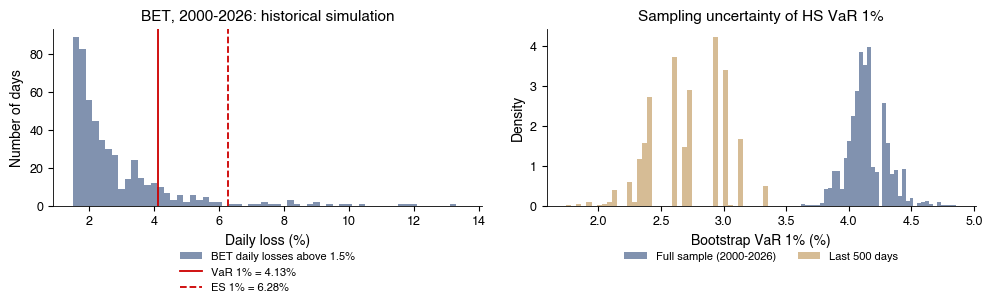

,full,w500
N,6670,500
start,2000-01-06,2024-09-12
var1,4.126959,2.711855
es1,6.278785,3.22082
var2_5,2.798908,2.054348
es2_5,4.569397,2.691839
ci_lo,3.847795,2.114385
ci_hi,4.456415,3.12267
n_beyond,67,5


In [16]:
# Solution
def b1_bet_hs():
    L = -100 * log_returns('bet')
    out = {}
    boots = {}
    for tag, x in [('full', L), ('w500', L.iloc[-500:])]:
        v1, e1 = hs_var_es(x, 0.01)
        v2, e2 = hs_var_es(x, 0.025)
        ci, bs = boot_ci(x.values, lambda y: hs_var_es(y, 0.01)[0])
        boots[tag] = bs
        out[tag] = dict(N=len(x), start=str(x.index[0].date()), var1=v1, es1=e1, var2_5=v2, es2_5=e2,
                        ci_lo=ci[0], ci_hi=ci[1], n_beyond=int((x >= v1).sum()))
    # graficul: coada pierderilor + distributiile bootstrap
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
    ax = axes[0]
    ax.hist(L[L > 1.5], bins=np.linspace(1.5, 13.5, 61), color=MainBlue, alpha=0.55, label='BET daily losses above 1.5%')
    ax.axvline(out['full']['var1'], color=IDAred, lw=1.3, label=f"VaR 1% = {out['full']['var1']:.2f}%")
    ax.axvline(out['full']['es1'], color=IDAred, ls='--', lw=1.3, label=f"ES 1% = {out['full']['es1']:.2f}%")
    ax.set_xlabel('Daily loss (%)')
    ax.set_ylabel('Number of days')
    ax.set_title('BET, 2000-2026: historical simulation')
    legend_outside_bottom(ax, 1, -0.2)
    ax = axes[1]
    ax.hist(boots['full'], bins=40, density=True, color=MainBlue, alpha=0.55, label='Full sample (2000-2026)')
    ax.hist(boots['w500'], bins=40, density=True, color=Amber, alpha=0.55, label='Last 500 days')
    ax.set_xlabel('Bootstrap VaR 1% (%)')
    ax.set_ylabel('Density')
    ax.set_title('Sampling uncertainty of HS VaR 1%')
    legend_outside_bottom(ax, 2, -0.2)
    plt.tight_layout()
    save_fig('ch7_sem_bet_hs')
    return out


pd.DataFrame(b1_bet_hs()).round(3)

In [17]:
# (c) asymptotic (i.i.d., HAC) and block-bootstrap intervals for VaR 1%
pd.DataFrame({'full': SX['b1_full'], 'last 500': SX['b1_w500']}).round(3)

,full,last 500
var1,4.127,2.712
f,0.008,0.016
se,0.160,0.273
se_hac,0.225,0.266
lo,3.813,2.177
hi,4.441,3.246
lo_hac,3.686,2.190
hi_hac,4.568,3.234
blk_lo,3.609,2.023
blk_hi,4.801,3.032


### B2. GPD fit and extreme-value VaR on BET [Solved]

- Threshold leaving the largest 5% of losses above it; $\hat\xi$, $\hat\beta$ with standard errors; VaR and ES at 1%, 0.5%, 0.1%; stability across thresholds.
- Interpretation: where do EVT and historical simulation agree?

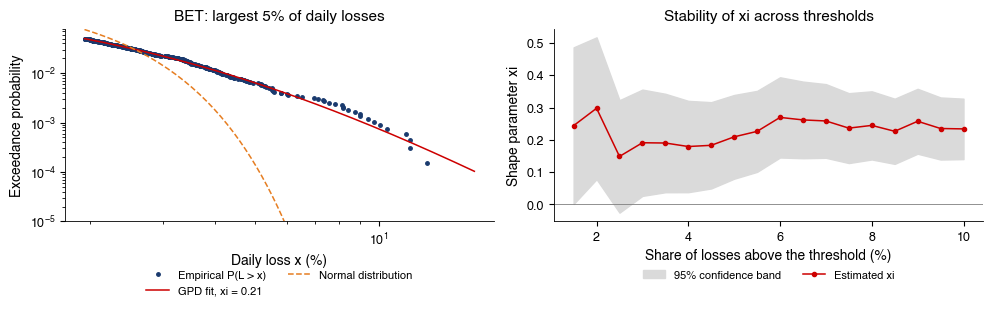

{'u': np.float64(1.9341864302995664),
 'xi': np.float64(0.20917979223399713),
 'beta': np.float64(1.1958177470341624),
 'nu': 334,
 'n': 6670,
 'se_xi': np.float64(0.06616337450274115),
 'se_beta': np.float64(0.10175416603506886),
 'evt_var1': np.float64(4.224892668482573),
 'evt_es1': np.float64(6.342930606256186),
 'hs_var1': np.float64(4.126958579751895),
 'hs_es1': np.float64(6.278784853593418),
 'n_beyond1': 67,
 'evt_var0_5': np.float64(5.474294112578411),
 'evt_es0_5': np.float64(7.922811130080035),
 'hs_var0_5': np.float64(5.378918259997512),
 'hs_es0_5': np.float64(7.855143286665594),
 'n_beyond0_5': 34,
 'evt_var0_1': np.float64(9.179474502863357),
 'evt_es0_1': np.float64(12.608048499964339),
 'hs_var0_1': np.float64(9.501589895769133),
 'hs_es0_1': np.float64(11.251818425971067),
 'n_beyond0_1': 7,
 'xi_range': [0.14851096707479988, 0.2976438909186965],
 'v0_1_range': [9.041439776125427, 9.51187997520639]}

In [18]:
# Solution
def b2_bet_gpd():
    L = (-100 * log_returns('bet')).values
    f = gpd_fit(L, 0.05)
    se_xi, se_beta = gpd_se(f)
    out = dict(u=f['u'], xi=f['xi'], beta=f['beta'], nu=f['nu'], n=f['n'], se_xi=se_xi, se_beta=se_beta)
    for a, tag in [(0.01, '1'), (0.005, '0_5'), (0.001, '0_1')]:
        v, e = gpd_var_es(f, a)
        hv, he = hs_var_es(L, a)
        out.update({f'evt_var{tag}': v, f'evt_es{tag}': e, f'hs_var{tag}': hv, f'hs_es{tag}': he,
                    f'n_beyond{tag}': int((L >= hv).sum())})
    # sensibilitatea la prag
    qs = np.linspace(0.10, 0.015, 18)          # proportia pierderilor peste prag
    xis, lo, hi, v01 = [], [], [], []
    for q in qs:
        g = gpd_fit(L, q)
        s = gpd_se(g)[0]
        xis.append(g['xi'])
        lo.append(g['xi'] - 1.96 * s)
        hi.append(g['xi'] + 1.96 * s)
        v01.append(gpd_var_es(g, 0.001)[0])
    out['xi_range'] = [float(min(xis)), float(max(xis))]
    out['v0_1_range'] = [float(min(v01)), float(max(v01))]
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
    ax = axes[0]
    xs = np.sort(L[L > f['u']])
    emp = (1 - np.arange(len(xs)) / len(xs)) * f['nu'] / f['n']
    ax.loglog(xs, emp, 'o', ms=2.5, color=MainBlue, label='Empirical P(L > x)')
    xx = np.linspace(f['u'], xs[-1] * 1.3, 200)
    ax.loglog(xx, f['nu'] / f['n'] * stats.genpareto.sf(xx - f['u'], f['xi'], scale=f['beta']), color=IDAred,
              label=f"GPD fit, xi = {f['xi']:.2f}")
    ax.loglog(xx, stats.norm.sf(xx, L.mean(), L.std()), color=Orange, ls='--', label='Normal distribution')
    ax.set_ylim(1e-5, 0.08)
    ax.set_xlabel('Daily loss x (%)')
    ax.set_ylabel('Exceedance probability')
    ax.set_title('BET: largest 5% of daily losses')
    legend_outside_bottom(ax, 2, -0.2)
    ax = axes[1]
    ax.fill_between(100 * qs, lo, hi, color=LightGray, label='95% confidence band')
    ax.plot(100 * qs, xis, 'o-', ms=3, color=IDAred, label='Estimated xi')
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xlabel('Share of losses above the threshold (%)')
    ax.set_ylabel('Shape parameter xi')
    ax.set_title('Stability of xi across thresholds')
    legend_outside_bottom(ax, 2, -0.2)
    plt.tight_layout()
    save_fig('ch7_sem_bet_gpd')
    return out


b2_bet_gpd()

In [19]:
# (e) extremal index and declustered GPD
print(extremal_index(loss['bet'].values, 0.05))
extremal_index(loss['bet'].values, 0.01)

{'u': np.float64(1.9341864302995664), 'N': 334, 'theta': np.float64(0.32078876105010007), 'n_clusters': 100, 'mean_size': 3.34, 'xi': np.float64(0.20917979223399713), 'se_xi': np.float64(0.06616337450274115), 'xi_c': np.float64(0.268679519873381), 'se_xi_c': np.float64(0.12686795198733808), 'beta_c': np.float64(1.4742231495306608), 'se_xi_eff': np.float64(0.11681754503612903)}


{'u': np.float64(4.126958579751895),
 'N': 67,
 'theta': np.float64(0.39791070574334986),
 'n_clusters': 27,
 'mean_size': 2.4814814814814814,
 'xi': np.float64(0.07321034769304616),
 'se_xi': np.float64(0.13111351185509657),
 'xi_c': np.float64(-0.34430900963060845),
 'se_xi_c': np.float64(0.12618778993166016),
 'beta_c': np.float64(4.181159464672045),
 'se_xi_eff': np.float64(0.20785220595817536)}

### B3. Filtered vs historical simulation on Bitcoin [Proposed]

- AR(1)-GARCH(1,1), filtered VaR and ES 1% for the next day vs historical simulation; exceedances in the last two years. Model: B1.
- Interpretation: which method misses more often?

In [ ]:
# Your code here


### B4. Cornish–Fisher vs empirical quantiles [Proposed]

- Five series; Normal, Cornish–Fisher and historical VaR at 1% and 2.5% with a bootstrap interval. Model: A1, B1.
- Interpretation: why does Cornish–Fisher overshoot?

In [ ]:
# Your code here


### B5. Component VaR of a four-asset portfolio [Proposed]

- Equal weights in SPY, TLT, GLD, Bitcoin; Normal VaR 1% with Euler contributions and historical ES 2.5% contributions. Model: A5.
- Interpretation: is an equally weighted portfolio equally risky in each asset?

In [ ]:
# Your code here


### B6. How precise is an ES estimate? [Proposed]

- ES 2.5% of the S&P 500 and BET: i.i.d. and moving-block (20 days) bootstrap intervals. Model: B1.
- Interpretation: how many observations does each ES average?

In [ ]:
# Your code here


### B7. CAViaR on BET [Proposed]

- Symmetric absolute value CAViaR at 1%, estimated on 2000–2015 by the pinball loss; out of sample 2016–2026 vs FHS and 500-day historical simulation; the COVID-19 window. Model: B3.
- Interpretation: how does CAViaR react to the COVID-19 crash compared with FHS?

In [ ]:
# Your code here


## Part C — capital for a BVB blue-chip portfolio vs an S&P 500 portfolio [Proposed]

- How much capital does a ES 2.5% require for 1 million invested in eight BVB blue chips (equal weights) versus SPY, over the last ten years?
- 10-day horizon, a stressed 12-month window, liquidity horizons of 10 or 20 days.

In [ ]:
# Your code here
